# INTELLIGENT SYSTEM DEVELOPMENT - ASSIGNMENT 03

## Ứng dụng 2: Vietnam House Price Regression

**Dataset:** Vietnam Housing Dataset 2024  
**Target:** `Price_BillionVND`  
**Bài toán:** Regression  
**Mục tiêu:** Dự đoán giá nhà theo đơn vị tỷ VND từ diện tích, vị trí và thuộc tính bất động sản.

---

### 1. Định nghĩa bài toán

- **Đầu vào:** numeric property features và categorical location/property features.
- **Đầu ra:** giá dự đoán theo tỷ VND.
- **Đánh giá:** so sánh 5 regression models với Improved DNN. DL baseline của giảng viên được điều chỉnh cho regression.


---

### 2. Thiết lập môi trường

Import thư viện và helper cho EDA, parsing unit và preprocessing.


In [1]:
from pathlib import Path
from datetime import datetime, timezone
import json
import joblib
import math
import re
import warnings

warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

try:
    from IPython.display import display
except ImportError:

    def display(obj=None):
        if obj is not None:
            print(obj)


try:
    import matplotlib.pyplot as plt

    HAS_MATPLOTLIB = True
except ImportError:
    HAS_MATPLOTLIB = False

    class _NoPlotAxis:
        def __getattr__(self, name):
            def _method(*args, **kwargs):
                return self

            return _method

    class _NoPlotAxes(list):
        def ravel(self):
            return self

    class _NoPlot:
        def figure(self, *args, **kwargs):
            print("Matplotlib is not installed; plot skipped.")
            return _NoPlotAxis()

        def subplots(self, nrows=1, ncols=1, *args, **kwargs):
            print("Matplotlib is not installed; plot skipped.")
            fig = _NoPlotAxis()
            if nrows == 1 and ncols == 1:
                return fig, _NoPlotAxis()
            axes = _NoPlotAxes([_NoPlotAxis() for _ in range(nrows * ncols)])
            return fig, axes

        def __getattr__(self, name):
            def _method(*args, **kwargs):
                return _NoPlotAxis()

            return _method

    plt = _NoPlot()

from sklearn.base import clone
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.dummy import DummyClassifier, DummyRegressor
from sklearn.ensemble import (
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    RandomForestClassifier,
    RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    mean_squared_error,
    precision_score,
    r2_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, OneHotEncoder, StandardScaler
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor

SEED = 42
np.random.seed(SEED)

pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 140)


def find_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    candidates = [start, *start.parents]
    for candidate in candidates:
        if (candidate / "datasets").exists() and (candidate / "pipeline").exists():
            return candidate
    return start


ROOT = find_project_root()
DATA_DIR = ROOT / "datasets"
ARTIFACT_DIR = ROOT / "artifacts"

print("Project root:", ROOT)


def display_df(title, df, rows=10):
    print(title)
    display(df.head(rows))


def missing_table(df):
    result = pd.DataFrame(
        {
            "missing_count": df.isna().sum(),
            "missing_pct": df.isna().mean().mul(100).round(2),
            "dtype": df.dtypes.astype(str),
            "n_unique": df.nunique(dropna=True),
        }
    )
    return result.sort_values(["missing_pct", "missing_count"], ascending=False)


def iqr_outlier_table(df, columns):
    rows = []
    for col in columns:
        s = pd.to_numeric(df[col], errors="coerce").dropna()
        if s.empty:
            continue
        q1, q3 = s.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo = q1 - 1.5 * iqr
        hi = q3 + 1.5 * iqr
        rows.append(
            {
                "feature": col,
                "min": s.min(),
                "q1": q1,
                "median": s.median(),
                "q3": q3,
                "max": s.max(),
                "iqr_lower": lo,
                "iqr_upper": hi,
                "outlier_count": int(((s < lo) | (s > hi)).sum()),
                "outlier_pct": round(((s < lo) | (s > hi)).mean() * 100, 2),
            }
        )
    return pd.DataFrame(rows)


def make_one_hot_encoder(**kwargs):
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True, **kwargs)
    except TypeError:
        try:
            return OneHotEncoder(handle_unknown="ignore", sparse=True, **kwargs)
        except TypeError:
            legacy_kwargs = {
                k: v
                for k, v in kwargs.items()
                if k not in {"min_frequency", "max_categories"}
            }
            return OneHotEncoder(handle_unknown="ignore", sparse=True, **legacy_kwargs)


def to_dense_array(matrix):
    if hasattr(matrix, "toarray"):
        matrix = matrix.toarray()
    return np.asarray(matrix, dtype=np.float32)


def dense_transformer():
    return FunctionTransformer(to_dense_array, accept_sparse=True, validate=False)


def assert_no_nan_inf(matrix, name):
    values = matrix.data if hasattr(matrix, "data") else np.asarray(matrix)
    assert np.isfinite(values).all(), f"{name} contains NaN or Inf"
    print(f"{name}: shape={matrix.shape}, finite_values=OK")


def normalize_text_value(value):
    if pd.isna(value):
        return "Unknown"
    text = re.sub(r"\s+", " ", str(value).strip())
    text = text.strip(".")
    return text if text else "Unknown"


def parse_number_with_vietnamese_units(value):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    text = str(value).lower().strip()
    text = text.replace(",", ".")
    match = re.search(r"[-+]?\d*\.?\d+", text)
    return float(match.group(0)) if match else np.nan


def parse_area_m2(value):
    return parse_number_with_vietnamese_units(value)


def parse_price_billion_vnd(value, area_m2=None):
    if pd.isna(value):
        return np.nan
    if isinstance(value, (int, float, np.number)):
        return float(value)
    text = str(value).lower().strip().replace(",", ".")
    number = parse_number_with_vietnamese_units(text)
    if np.isnan(number):
        return np.nan
    if "triệu/m" in text or "tr/m" in text:
        return (
            number * area_m2 / 1000 if area_m2 is not None and area_m2 > 0 else np.nan
        )
    if "triệu" in text:
        return number / 1000
    return number


def split_vietnamese_address(address):
    parts = [
        normalize_text_value(p)
        for p in str(address).split(",")
        if normalize_text_value(p) != "Unknown"
    ]
    city = parts[-1] if len(parts) >= 1 else "Unknown"
    district = parts[-2] if len(parts) >= 2 else "Unknown"
    ward_or_street = parts[-3] if len(parts) >= 3 else "Unknown"
    city = {
        "Hà Nội.": "Hà Nội",
        "TP. Hồ Chí Minh": "Hồ Chí Minh",
        "Tp Hồ Chí Minh": "Hồ Chí Minh",
    }.get(city, city)
    return pd.Series(
        {"city": city, "district": district, "ward_or_street": ward_or_street}
    )

Project root: c:\DATA\assign


---

### 3. Nạp dữ liệu

Nạp dataset nhà đất Việt Nam và xác định target giá.


In [2]:
HOUSE_PATH = DATA_DIR / "housing_price" / "vietnam_housing_dataset.csv"
assert HOUSE_PATH.exists(), f"Missing dataset: {HOUSE_PATH}"

house_raw = pd.read_csv(HOUSE_PATH)
HOUSE_RAW_TARGET = "Price"

print("Dataset path:", HOUSE_PATH)
print("Shape:", house_raw.shape)
display(house_raw.head())
display(house_raw.dtypes.to_frame("dtype").T)

Dataset path: c:\DATA\assign\datasets\housing_price\vietnam_housing_dataset.csv
Shape: (30229, 12)


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.60
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",60.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,7.50
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",90.0,6.0,13.0,Đông - Bắc,Đông - Bắc,5.0,NaN,NaN,Sale contract,NaN,8.90
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",54.0,NaN,3.5,Tây - Nam,Tây - Nam,2.0,2.0,3.0,Have certificate,Full,5.35
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",92.0,NaN,NaN,Đông - Nam,Đông - Nam,2.0,4.0,4.0,Have certificate,Full,6.90


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
dtype,str,float64,float64,float64,str,str,float64,float64,float64,str,str,float64


**Nhận xét.** Dataset có 30,229 dòng và 12 cột, không có duplicate. Quy mô này đủ cho regression và cho phép so sánh ML với DNN mà không phải thay dataset.


---

### 4. Chuẩn hóa đơn vị và location

Chuẩn hóa diện tích/giá và tách `Address` thành city, district, ward/street.


In [3]:
house = house_raw.copy()

house["Area_m2"] = house["Area"].apply(parse_area_m2)
house["Price_BillionVND"] = [
    parse_price_billion_vnd(price, area)
    for price, area in zip(house["Price"], house["Area_m2"])
]
house["Frontage_m"] = house["Frontage"].apply(parse_number_with_vietnamese_units)
house["Access_Road_m"] = house["Access Road"].apply(parse_number_with_vietnamese_units)

for col in ["Floors", "Bedrooms", "Bathrooms"]:
    house[col] = pd.to_numeric(house[col], errors="coerce")

location_parts = house["Address"].apply(split_vietnamese_address)
house = pd.concat([house, location_parts], axis=1)

for col in [
    "Legal status",
    "Furniture state",
    "House direction",
    "Balcony direction",
    "city",
    "district",
    "ward_or_street",
]:
    house[col] = house[col].apply(normalize_text_value)

house["price_per_m2_million"] = house["Price_BillionVND"] * 1000 / house["Area_m2"]

display(
    house[
        [
            "Address",
            "city",
            "district",
            "Area",
            "Area_m2",
            "Price",
            "Price_BillionVND",
            "price_per_m2_million",
        ]
    ].head()
)

,Address,city,district,Area,Area_m2,Price,Price_BillionVND,price_per_m2_million
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",Hưng Yên,Văn Giang,84.0,84.0,8.60,8.60,102.380952
1,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Hưng Yên,Văn Giang,60.0,60.0,7.50,7.50,125.000000
2,"Dự án The Crown - Vinhomes Ocean Park 3, Xã Ng...",Hưng Yên,Văn Giang,90.0,90.0,8.90,8.90,98.888889
3,"Đường Nguyễn Văn Khối, Phường 11, Gò Vấp, Hồ C...",Hồ Chí Minh,Gò Vấp,54.0,54.0,5.35,5.35,99.074074
4,"Đường Quang Trung, Phường 8, Gò Vấp, Hồ Chí Minh",Hồ Chí Minh,Gò Vấp,92.0,92.0,6.90,6.90,75.000000


**Nhận xét.** Sau parsing, model dùng `Price_BillionVND` làm target và tạo thêm `price_per_m2_million` cho EDA. Biến này không đưa vào X vì được tính trực tiếp từ `Price` và `Area_m2`.


---

### 5. Kiểm tra chất lượng dữ liệu

Kiểm tra missing values, duplicates, invalid values và categorical consistency.


In [4]:
display(missing_table(house_raw))

print("Duplicate rows:", int(house_raw.duplicated().sum()))

invalid_checks = pd.DataFrame(
    [
        {
            "check": "Price_BillionVND <= 0 or missing",
            "count": int(
                (
                    house["Price_BillionVND"].isna() | (house["Price_BillionVND"] <= 0)
                ).sum()
            ),
        },
        {
            "check": "Area_m2 <= 0 or missing",
            "count": int((house["Area_m2"].isna() | (house["Area_m2"] <= 0)).sum()),
        },
        {"check": "Area_m2 < 10", "count": int((house["Area_m2"] < 10).sum())},
        {"check": "Floors < 0", "count": int((house["Floors"] < 0).sum())},
        {"check": "Bedrooms < 0", "count": int((house["Bedrooms"] < 0).sum())},
        {"check": "Bathrooms < 0", "count": int((house["Bathrooms"] < 0).sum())},
    ]
)
display(invalid_checks)

for col in [
    "city",
    "district",
    "Legal status",
    "Furniture state",
    "House direction",
    "Balcony direction",
]:
    print(f"\nTop values - {col}")
    display(house[col].value_counts(dropna=False).head(12).to_frame("count"))

,missing_count,missing_pct,dtype,n_unique
Balcony direction,24983,82.65,str,8
House direction,21239,70.26,str,8
Furniture state,14119,46.71,str,2
Access Road,13297,43.99,float64,140
Frontage,11564,38.25,float64,407
Bathrooms,7074,23.40,float64,9
Bedrooms,5162,17.08,float64,9
Legal status,4506,14.91,str,2
Floors,3603,11.92,float64,10
Address,0,0.00,str,10265


Duplicate rows: 0


,check,count
0,Price_BillionVND <= 0 or missing,0
1,Area_m2 <= 0 or missing,0
2,Area_m2 < 10,6
3,Floors < 0,0
4,Bedrooms < 0,0
5,Bathrooms < 0,0



Top values - city


,count
city,
Hồ Chí Minh,11778
Hà Nội,10457
Bình Dương,1672
Đà Nẵng,1437
Đồng Nai,829
Hải Phòng,789
Khánh Hòa,743
Hưng Yên,405
Long An,339


...

,count
Furniture state,
Unknown,14119
Full,10591
Basic,5519



Top values - House direction


,count
House direction,
Unknown,21239
Đông - Nam,1916
Đông - Bắc,1180
Tây - Nam,1152
Tây - Bắc,1125
Nam,1042
Đông,952
Bắc,832
Tây,791



Top values - Balcony direction


,count
Balcony direction,
Unknown,24983
Đông - Nam,1087
Nam,701
Đông - Bắc,670
Tây - Nam,646
Tây - Bắc,640
Đông,577
Bắc,474
Tây,451


**Nhận xét.** Missing tập trung ở `Balcony direction` (82.65%), `House direction` (70.26%), `Furniture state` (46.71%), `Access Road` (43.99%) và `Frontage` (38.25%). Vì missing quá nhiều, drop rows sẽ làm mất dữ liệu lớn nên dùng imputation/`Unknown` hợp lý hơn.


---

### 6. Làm sạch dữ liệu

Loại record có target hoặc area không hợp lệ.


In [5]:
valid_house_mask = (
    house["Price_BillionVND"].notna()
    & house["Area_m2"].notna()
    & (house["Price_BillionVND"] > 0)
    & (house["Area_m2"] >= 10)
    & (house["Area_m2"] <= 1000)
)

house_model_df = house.loc[valid_house_mask].copy().reset_index(drop=True)

print("Rows before cleaning:", len(house))
print("Rows after cleaning:", len(house_model_df))
print("Removed rows:", len(house) - len(house_model_df))

Rows before cleaning: 30229
Rows after cleaning: 30223
Removed rows: 6


**Nhận xét.** Cleaning chỉ loại 6 dòng, từ 30,229 còn 30,223 dòng. Ngưỡng area tối thiểu 10 m2 loại record bất khả thi mà hầu như không làm thay đổi quy mô dữ liệu.


---

### 7. Phân tích target

Quan sát phân phối giá và chuẩn bị `log1p(Price_BillionVND)` cho modeling.


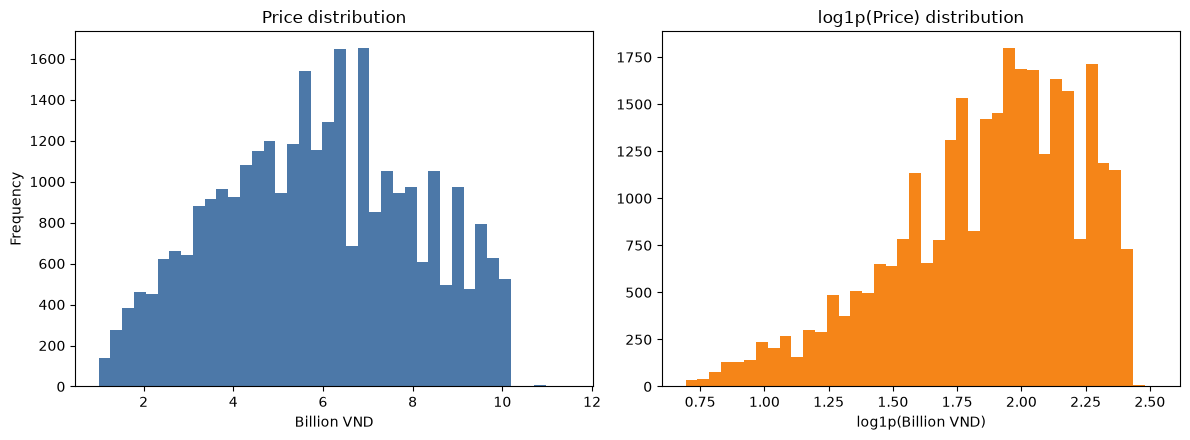

,count,mean,std,min,25%,50%,75%,max
Price_BillionVND,30223.0,5.872565,2.211658,1.000000,4.200000,5.900000,7.500000,11.500000
Log_Price_BillionVND,30223.0,1.867914,0.361165,0.693147,1.648659,1.931521,2.140066,2.525729


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(house_model_df["Price_BillionVND"], bins=40, color="#4C78A8")
axes[0].set_title("Price distribution")
axes[0].set_xlabel("Billion VND")
axes[0].set_ylabel("Frequency")

house_model_df["Log_Price_BillionVND"] = np.log1p(house_model_df["Price_BillionVND"])
axes[1].hist(house_model_df["Log_Price_BillionVND"], bins=40, color="#F58518")
axes[1].set_title("log1p(Price) distribution")
axes[1].set_xlabel("log1p(Billion VND)")
plt.tight_layout()
plt.show()

display(house_model_df[["Price_BillionVND", "Log_Price_BillionVND"]].describe().T)

**Nhận xét.** `Price_BillionVND` có min 1.0, median 5.9, mean 5.873 và max 11.5. Skew của target gần 0 (-0.029), nhưng log target vẫn được dùng để training ổn định và giữ metric cuối ở đơn vị tỷ VND.


---

### 8. Phân phối numeric features

Kiểm tra diện tích, mặt tiền, đường vào, số tầng và số phòng.


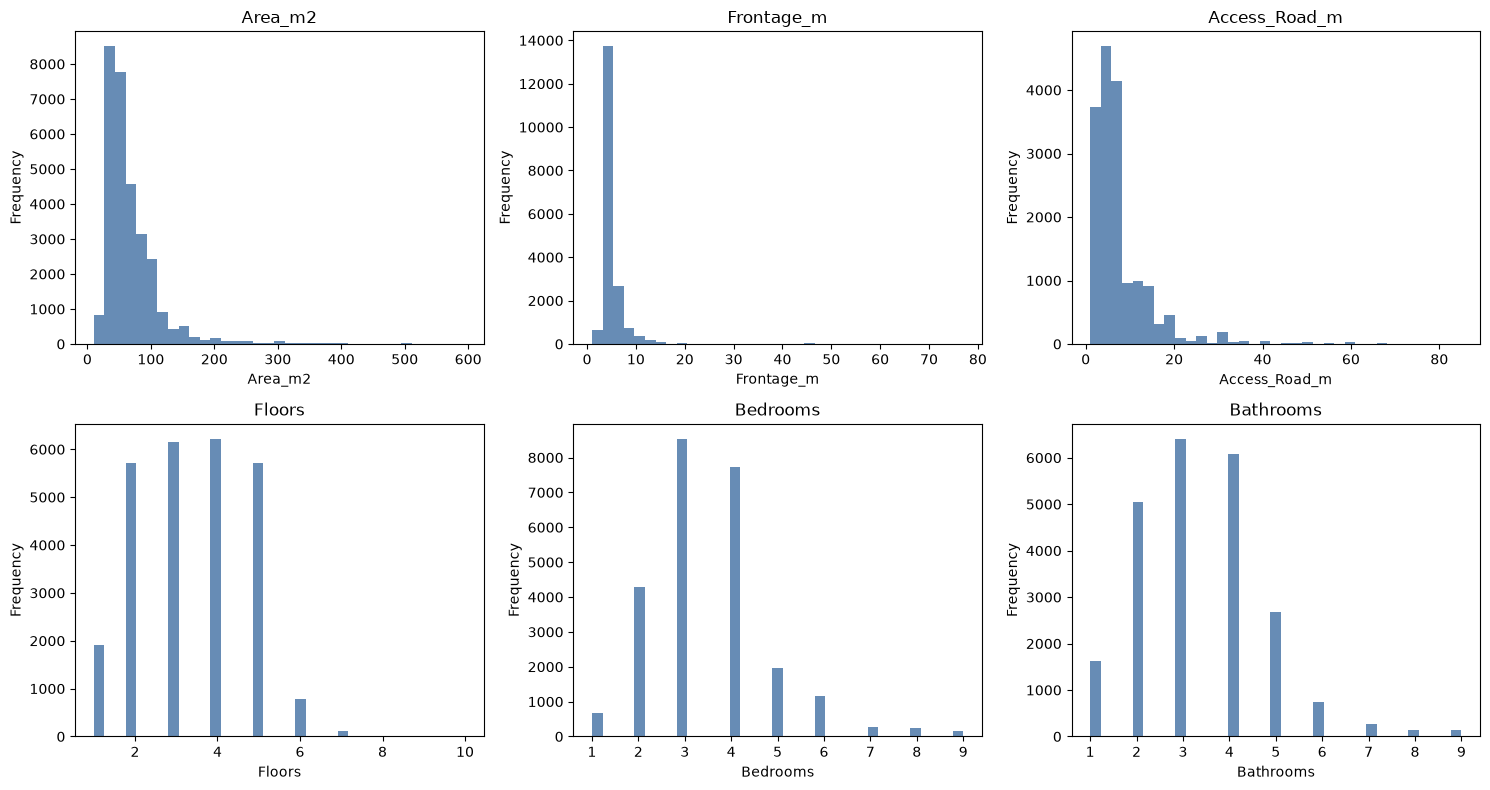

,count,mean,std,min,25%,50%,75%,max
Area_m2,30223.0,68.511195,48.066472,10.0,40.0,56.0,80.0,595.0
Frontage_m,18663.0,5.360016,4.340972,1.0,4.0,4.5,5.0,77.0
Access_Road_m,16930.0,7.854432,7.451524,1.0,4.0,6.0,10.0,85.0
Floors,26620.0,3.410406,1.328940,1.0,2.0,3.0,4.0,10.0
Bedrooms,25061.0,3.511272,1.309125,1.0,3.0,3.0,4.0,9.0
Bathrooms,23149.0,3.347013,1.400175,1.0,2.0,3.0,4.0,9.0


,feature,min,q1,median,q3,max,iqr_lower,iqr_upper,outlier_count,outlier_pct
0,Area_m2,10.000000,40.000000,56.000000,80.0,595.0,-20.000000,140.000000,1636,5.41
1,Frontage_m,1.000000,4.000000,4.500000,5.0,77.0,2.500000,6.500000,2303,12.34
2,Access_Road_m,1.000000,4.000000,6.000000,10.0,85.0,-5.000000,19.000000,1110,6.56
3,Floors,1.000000,2.000000,3.000000,4.0,10.0,-1.000000,7.000000,5,0.02
4,Bedrooms,1.000000,3.000000,3.000000,4.0,9.0,1.500000,5.500000,2532,10.10
5,Bathrooms,1.000000,2.000000,3.000000,4.0,9.0,-1.000000,7.000000,287,1.24
6,Price_BillionVND,1.000000,4.200000,5.900000,7.5,11.5,-0.750000,12.450000,0,0.00
7,price_per_m2_million,2.109334,64.330409,102.249489,145.0,550.0,-56.673977,266.004386,175,0.58


In [7]:
HOUSE_NUMERIC_FEATURES = [
    "Area_m2",
    "Frontage_m",
    "Access_Road_m",
    "Floors",
    "Bedrooms",
    "Bathrooms",
]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.ravel()
for ax, col in zip(axes, HOUSE_NUMERIC_FEATURES):
    ax.hist(house_model_df[col].dropna(), bins=35, color="#4C78A8", alpha=0.85)
    ax.set_title(col)
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")
plt.tight_layout()
plt.show()

display(house_model_df[HOUSE_NUMERIC_FEATURES].describe().T)
display(
    iqr_outlier_table(
        house_model_df,
        HOUSE_NUMERIC_FEATURES + ["Price_BillionVND", "price_per_m2_million"],
    )
)

**Nhận xét.** `Area_m2` có median 56 m2, mean 68.51 m2 và max 595 m2, cho thấy có một số listing diện tích lớn. `Bathrooms` và `Bedrooms` có correlation với price cao hơn area thô.


---

### 9. Phân phối categorical features

Kiểm tra location, pháp lý, nội thất và hướng nhà.


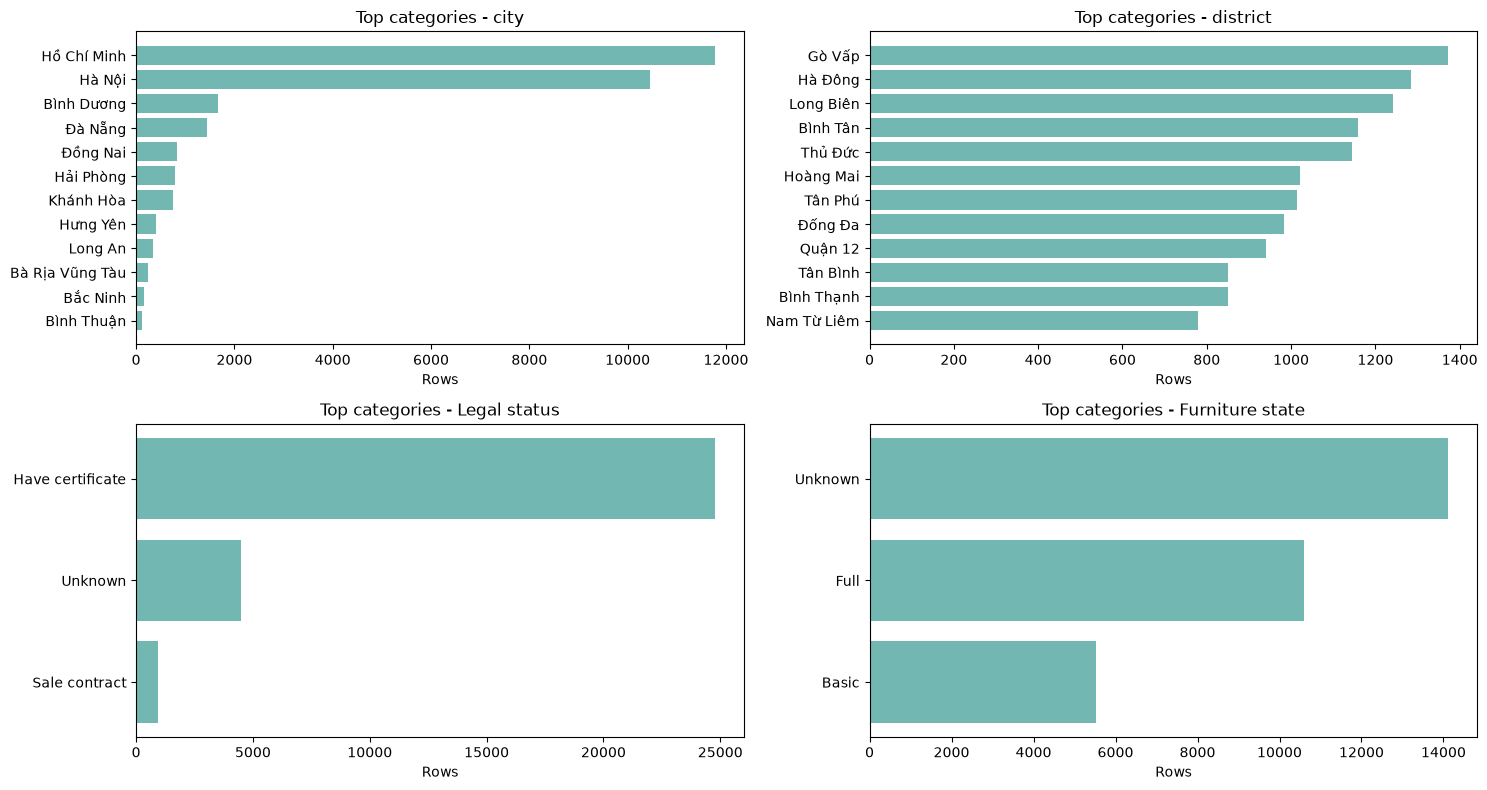

In [8]:
HOUSE_CATEGORICAL_FEATURES = [
    "city",
    "district",
    "Legal status",
    "Furniture state",
    "House direction",
    "Balcony direction",
]

fig, axes = plt.subplots(2, 2, figsize=(15, 8))
categorical_to_plot = ["city", "district", "Legal status", "Furniture state"]
for ax, col in zip(axes.ravel(), categorical_to_plot):
    counts = house_model_df[col].value_counts().head(12).sort_values()
    ax.barh(counts.index, counts.values, color="#72B7B2")
    ax.set_title(f"Top categories - {col}")
    ax.set_xlabel("Rows")
plt.tight_layout()
plt.show()

**Nhận xét.** Hai thị trường lớn nhất là Hồ Chí Minh (11,774 dòng) và Hà Nội (10,456 dòng). `district` có 343 giá trị và `city` có 78 giá trị, nên cần one-hot encoding có `handle_unknown='ignore'`.


---

### 10. Quan hệ feature-target

Phân tích giá theo area, location, số phòng và pháp lý.


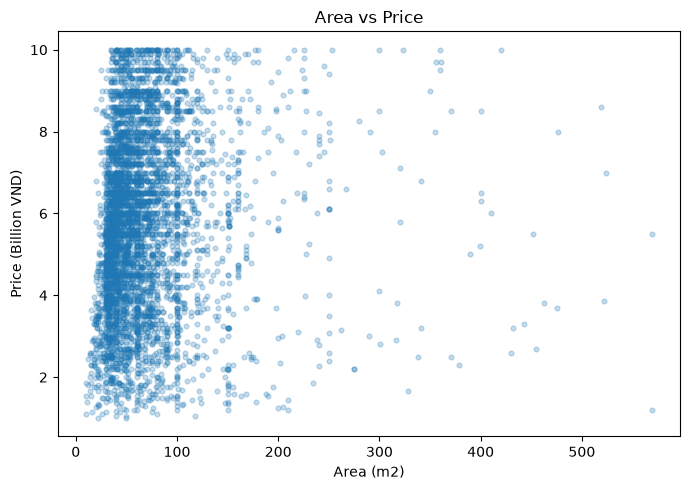


Price by city


,count,median,mean
city,,,
Bán nhà chính chủ Phó Đức Chính khu Bà Chiểu - trung tâm Bình Thạnh giá cực tốt,1,9.000,9.000000
Quận 8,1,8.950,8.950000
Đường số 11,1,7.900,7.900000
TP. HCM,2,7.900,7.900000
TpHCM,1,7.900,7.900000
Hưng Yên,405,7.800,7.899901
Nghệ An,28,7.750,7.306071
Quảng Ninh (Ngã 3 đường Hòn Gai cũ),1,7.600,7.600000
Quảng Ninh,110,7.300,6.983727



Price by district


,count,median,mean
district,,,
Kim Sơn,1,10.00,10.000000
Bắc Giang,3,9.90,7.066667
Thường Tín,26,9.90,7.636538
quận Tân Bình,1,9.50,9.500000
Thị Xã Phú Mỹ,1,9.40,9.400000
Huyện Phù Cát,1,9.40,9.400000
Huyện Văn Giang,11,9.10,8.318182
Phường 3,1,8.95,8.950000
Văn Lâm,5,8.86,8.642000



Price by Legal status


...

,count,median,mean
Furniture state,,,
Full,10587,6.200,6.137923
Unknown,14118,5.900,5.910868
Basic,5518,5.025,5.265442



Price by Bedrooms


,count,median,mean
Bedrooms,,,
9.0,161,7.80,7.759130
7.0,281,7.50,7.334591
6.0,1160,7.50,7.284422
8.0,246,7.40,7.172033
5.0,1964,7.20,7.088401
4.0,7739,6.50,6.423649
3.0,8540,5.25,5.324742
1.0,684,4.50,4.828596
2.0,4286,3.99,4.383903



Price by Bathrooms


,count,median,mean
Bathrooms,,,
7.0,264,7.94,7.561591
9.0,150,7.70,7.529933
6.0,746,7.60,7.467962
5.0,2688,7.20,7.193010
8.0,137,7.19,7.113504
4.0,6083,6.30,6.370396
3.0,6409,5.50,5.517681
2.0,5039,4.15,4.510395
1.0,1633,3.69,4.241194


In [9]:
sample_scatter = house_model_df.sample(
    min(5000, len(house_model_df)), random_state=SEED
)
plt.figure(figsize=(7, 5))
plt.scatter(
    sample_scatter["Area_m2"], sample_scatter["Price_BillionVND"], alpha=0.25, s=12
)
plt.xlabel("Area (m2)")
plt.ylabel("Price (Billion VND)")
plt.title("Area vs Price")
plt.tight_layout()
plt.show()

for col in [
    "city",
    "district",
    "Legal status",
    "Furniture state",
    "Bedrooms",
    "Bathrooms",
]:
    summary = (
        house_model_df.groupby(col)["Price_BillionVND"]
        .agg(["count", "median", "mean"])
        .sort_values("median", ascending=False)
        .head(12)
    )
    print(f"\nPrice by {col}")
    display(summary)

**Nhận xét.** Median price thay đổi mạnh theo location; nhóm city/location cao nhất trong dữ liệu đạt khoảng 7.9-9.0 tỷ VND. Điều này xác nhận location là tín hiệu quan trọng, dù một số chuỗi địa chỉ vẫn còn nhiễu do parsing từ `Address`.


---

### 11. Correlation / association

Đọc correlation cho numeric features và median target cho categorical groups.


,corr_with_price
Price_BillionVND,1.000000
Log_Price_BillionVND,0.979281
Bathrooms,0.433986
Bedrooms,0.389258
Floors,0.331666
Access_Road_m,0.164234
Area_m2,0.097347
Frontage_m,0.047526


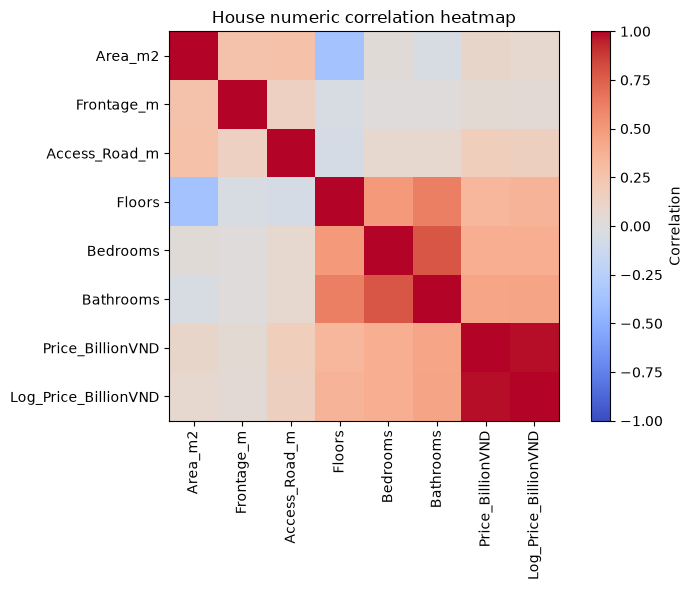

In [10]:
corr_cols = HOUSE_NUMERIC_FEATURES + ["Price_BillionVND", "Log_Price_BillionVND"]
house_corr = house_model_df[corr_cols].corr(numeric_only=True)
display(
    house_corr["Price_BillionVND"]
    .sort_values(key=lambda s: s.abs(), ascending=False)
    .to_frame("corr_with_price")
)

plt.figure(figsize=(8, 6))
plt.imshow(house_corr, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlation")
plt.xticks(range(len(corr_cols)), corr_cols, rotation=90)
plt.yticks(range(len(corr_cols)), corr_cols)
plt.title("House numeric correlation heatmap")
plt.tight_layout()
plt.show()

**Nhận xét.** Correlation với price cao nhất là `Bathrooms` (0.434), `Bedrooms` (0.389) và `Floors` (0.332), trong khi `Area_m2` chỉ đạt 0.097. Giá nhà vì vậy phụ thuộc vào tổ hợp thuộc tính và location hơn là diện tích đơn lẻ.


---

### 12. Leakage analysis

Loại `Price`, `Log_Price_BillionVND` và `price_per_m2_million` khỏi X.


In [11]:
leakage_report = {
    "target": "Price_BillionVND",
    "excluded_from_X": [
        "Price",
        "Price_BillionVND",
        "Log_Price_BillionVND",
        "price_per_m2_million",
        "Address",
    ],
    "price_per_m2_reason": "computed from target and area; EDA only",
    "raw_address_reason": "high-cardinality text; derive city/district instead",
    "duplicates_after_cleaning": int(house_model_df.duplicated().sum()),
}
print(json.dumps(leakage_report, indent=2, ensure_ascii=False))

{
  "target": "Price_BillionVND",
  "excluded_from_X": [
    "Price",
    "Price_BillionVND",
    "Log_Price_BillionVND",
    "price_per_m2_million",
    "Address"
  ],
  "price_per_m2_reason": "computed from target and area; EDA only",
  "raw_address_reason": "high-cardinality text; derive city/district instead",
  "duplicates_after_cleaning": 0
}


**Nhận xét.** Leakage report loại `Price`, `Price_BillionVND`, `Log_Price_BillionVND`, `price_per_m2_million` và raw `Address` khỏi X. Feature cuối chỉ còn thông tin có thể biết trước khi dự đoán.


---

### 13. Biểu diễn dữ liệu

Record thô được chuyển thành numeric vector và one-hot categorical representation.


In [12]:
HOUSE_TARGET = "Price_BillionVND"
HOUSE_FEATURES = HOUSE_NUMERIC_FEATURES + HOUSE_CATEGORICAL_FEATURES

X_house = house_model_df[HOUSE_FEATURES].copy()
y_house = house_model_df[HOUSE_TARGET].copy()
y_house_log = house_model_df["Log_Price_BillionVND"].copy()

display_df("One raw record", house_raw, rows=1)
display_df("One model-ready record before sklearn preprocessing", X_house, rows=1)
print("Feature columns:", HOUSE_FEATURES)
print("Feature matrix shape:", X_house.shape)
print("Target shape:", y_house.shape)

One raw record


,Address,Area,Frontage,Access Road,House direction,Balcony direction,Floors,Bedrooms,Bathrooms,Legal status,Furniture state,Price
0,"Dự án The Empire - Vinhomes Ocean Park 2, Xã L...",84.0,NaN,NaN,NaN,NaN,4.0,NaN,NaN,Have certificate,NaN,8.6


One model-ready record before sklearn preprocessing


,Area_m2,Frontage_m,Access_Road_m,Floors,Bedrooms,Bathrooms,city,district,Legal status,Furniture state,House direction,Balcony direction
0,84.0,NaN,NaN,4.0,NaN,NaN,Hưng Yên,Văn Giang,Have certificate,Unknown,Unknown,Unknown


Feature columns: ['Area_m2', 'Frontage_m', 'Access_Road_m', 'Floors', 'Bedrooms', 'Bathrooms', 'city', 'district', 'Legal status', 'Furniture state', 'House direction', 'Balcony direction']
Feature matrix shape: (30223, 12)
Target shape: (30223,)


**Nhận xét.** X trước preprocessing có 12 feature; sau one-hot encoding, matrix train/test có 154 cột. Đây là lý do cần chuyển sparse matrix sang dense trước khi đưa vào NumPy DNN.


---

### 14. Preprocessing pipeline

Numeric và categorical features được xử lý bằng hai nhánh riêng.


In [13]:
house_numeric_preprocess = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

house_categorical_preprocess = Pipeline(
    [
        ("imputer", SimpleImputer(strategy="constant", fill_value="Unknown")),
        ("onehot", make_one_hot_encoder(min_frequency=20)),
    ]
)

house_preprocessor = ColumnTransformer(
    [
        ("numeric", house_numeric_preprocess, HOUSE_NUMERIC_FEATURES),
        ("categorical", house_categorical_preprocess, HOUSE_CATEGORICAL_FEATURES),
    ],
    remainder="drop",
)

X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_house,
    y_house,
    test_size=0.20,
    random_state=SEED,
)

X_train_h_ready = house_preprocessor.fit_transform(X_train_h)
X_test_h_ready = house_preprocessor.transform(X_test_h)

**Nhận xét.** Split tạo 24,178 dòng train và 6,045 dòng test. Preprocessor tạo matrix `(24178, 154)` và `(6045, 154)`, không có NaN/Inf.


---

### 15. Kiểm tra preprocessing

Xác nhận target không nằm trong X, split/preprocessor chạy được và transformed matrix hợp lệ.


In [14]:
assert HOUSE_TARGET not in X_house.columns
assert "Price" not in X_house.columns
assert "price_per_m2_million" not in X_house.columns
assert len(X_house) == len(y_house)
assert X_train_h_ready.shape[0] == len(y_train_h)
assert X_test_h_ready.shape[0] == len(y_test_h)
assert X_train_h_ready.shape[1] == X_test_h_ready.shape[1]

assert_no_nan_inf(X_train_h_ready, "X_train_h_ready")
assert_no_nan_inf(X_test_h_ready, "X_test_h_ready")

phase3_house_summary = {
    "dataset": str(HOUSE_PATH.relative_to(ROOT)),
    "target": HOUSE_TARGET,
    "task": "regression",
    "rows_after_cleaning": int(len(house_model_df)),
    "numeric_feature_count": int(len(HOUSE_NUMERIC_FEATURES)),
    "categorical_feature_count": int(len(HOUSE_CATEGORICAL_FEATURES)),
    "log_target_used_for_modeling": True,
    "excluded_leakage_features": [
        "Price",
        "Log_Price_BillionVND",
        "price_per_m2_million",
        "Address",
    ],
}
print(json.dumps(phase3_house_summary, indent=2, ensure_ascii=False))

X_train_h_ready: shape=(24178, 154), finite_values=OK
X_test_h_ready: shape=(6045, 154), finite_values=OK
{
  "dataset": "datasets\\housing_price\\vietnam_housing_dataset.csv",
  "target": "Price_BillionVND",
  "task": "regression",
  "rows_after_cleaning": 30223,
  "numeric_feature_count": 6,
  "categorical_feature_count": 6,
  "log_target_used_for_modeling": true,
  "excluded_leakage_features": [
    "Price",
    "Log_Price_BillionVND",
    "price_per_m2_million",
    "Address"
  ]
}


---

### 16. Baseline và 5 mô hình ML

Huấn luyện 5 mô hình regression:

1. Linear Regression
2. KNN Regressor
3. Decision Tree Regressor
4. Random Forest Regressor
5. Gradient Boosting Regressor


In [15]:
def regression_metrics_row(name, y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    y_pred = np.maximum(y_pred, 0)
    mse = mean_squared_error(y_true, y_pred)
    return {
        "Model": name,
        "MAE": mean_absolute_error(y_true, y_pred),
        "MSE": mse,
        "RMSE": float(np.sqrt(mse)),
        "R2": r2_score(y_true, y_pred),
        "MAPE": float(
            np.mean(np.abs((y_true - y_pred) / np.maximum(np.abs(y_true), 1e-8))) * 100
        ),
    }


def relu(x):
    return np.maximum(0, x)


def relu_derivative(x):
    return (x > 0).astype(float)


def teacher_forward_regression(X, params):
    z1 = X @ params["W1"] + params["b1"]
    h1 = relu(z1)
    z2 = h1 @ params["W2"] + params["b2"]
    h2 = relu(z2)
    y_hat = h2 @ params["W3"] + params["b3"]
    cache = {"X": X, "z1": z1, "h1": h1, "z2": z2, "h2": h2, "y_hat": y_hat}
    return y_hat, cache


def train_teacher_regression_dnn(
    X_train, y_train, input_dim, epochs=1000, learning_rate=0.01, seed=42
):
    rng = np.random.default_rng(seed)
    y_train = np.asarray(y_train, dtype=float).reshape(-1, 1)
    params = {
        "W1": rng.normal(size=(input_dim, 16)) * np.sqrt(2.0 / input_dim),
        "b1": np.zeros((1, 16)),
        "W2": rng.normal(size=(16, 8)) * np.sqrt(2.0 / 16),
        "b2": np.zeros((1, 8)),
        "W3": rng.normal(size=(8, 1)) * np.sqrt(2.0 / 8),
        "b3": np.zeros((1, 1)),
    }
    losses = []
    for epoch in range(epochs):
        y_hat, cache = teacher_forward_regression(X_train, params)
        loss = float(np.mean((y_hat - y_train) ** 2))
        losses.append(loss)
        n = len(X_train)
        dy = 2 * (y_hat - y_train) / n
        dW3 = cache["h2"].T @ dy
        db3 = np.sum(dy, axis=0, keepdims=True)
        dh2 = dy @ params["W3"].T
        dz2 = dh2 * relu_derivative(cache["z2"])
        dW2 = cache["h1"].T @ dz2
        db2 = np.sum(dz2, axis=0, keepdims=True)
        dh1 = dz2 @ params["W2"].T
        dz1 = dh1 * relu_derivative(cache["z1"])
        dW1 = cache["X"].T @ dz1
        db1 = np.sum(dz1, axis=0, keepdims=True)
        params["W3"] -= learning_rate * dW3
        params["b3"] -= learning_rate * db3
        params["W2"] -= learning_rate * dW2
        params["b2"] -= learning_rate * db2
        params["W1"] -= learning_rate * dW1
        params["b1"] -= learning_rate * db1
        if not np.isfinite(loss):
            break
    return params, losses


def improved_forward_regression(X, params):
    z1 = X @ params["W1"] + params["b1"]
    h1 = relu(z1)
    z2 = h1 @ params["W2"] + params["b2"]
    h2 = relu(z2)
    y_hat = h2 @ params["W3"] + params["b3"]
    cache = {"X": X, "z1": z1, "h1": h1, "z2": z2, "h2": h2, "y_hat": y_hat}
    return y_hat, cache


def train_improved_regression_dnn(
    X_train,
    y_train_scaled,
    X_val,
    y_val_scaled,
    hidden=(64, 32),
    epochs=350,
    learning_rate=0.01,
    batch_size=512,
    l2=1e-4,
    patience=30,
    seed=42,
):
    rng = np.random.default_rng(seed)
    input_dim = X_train.shape[1]
    h1, h2 = hidden
    y_train_scaled = np.asarray(y_train_scaled, dtype=float).reshape(-1, 1)
    y_val_scaled = np.asarray(y_val_scaled, dtype=float).reshape(-1, 1)
    params = {
        "W1": rng.normal(size=(input_dim, h1)) * np.sqrt(2.0 / input_dim),
        "b1": np.zeros((1, h1)),
        "W2": rng.normal(size=(h1, h2)) * np.sqrt(2.0 / h1),
        "b2": np.zeros((1, h2)),
        "W3": rng.normal(size=(h2, 1)) * np.sqrt(2.0 / h2),
        "b3": np.zeros((1, 1)),
    }
    history = {"train_loss": [], "val_loss": []}
    best_params = {k: v.copy() for k, v in params.items()}
    best_val = np.inf
    wait = 0
    for epoch in range(epochs):
        indices = rng.permutation(len(X_train))
        for start in range(0, len(indices), batch_size):
            batch_idx = indices[start : start + batch_size]
            xb = X_train[batch_idx]
            yb = y_train_scaled[batch_idx]
            y_hat, cache = improved_forward_regression(xb, params)
            n = len(xb)
            dy = 2 * (y_hat - yb) / n
            dW3 = cache["h2"].T @ dy + l2 * params["W3"] / n
            db3 = np.sum(dy, axis=0, keepdims=True)
            dh2 = dy @ params["W3"].T
            dz2 = dh2 * relu_derivative(cache["z2"])
            dW2 = cache["h1"].T @ dz2 + l2 * params["W2"] / n
            db2 = np.sum(dz2, axis=0, keepdims=True)
            dh1 = dz2 @ params["W2"].T
            dz1 = dh1 * relu_derivative(cache["z1"])
            dW1 = cache["X"].T @ dz1 + l2 * params["W1"] / n
            db1 = np.sum(dz1, axis=0, keepdims=True)
            params["W3"] -= learning_rate * dW3
            params["b3"] -= learning_rate * db3
            params["W2"] -= learning_rate * dW2
            params["b2"] -= learning_rate * db2
            params["W1"] -= learning_rate * dW1
            params["b1"] -= learning_rate * db1

        train_pred, _ = improved_forward_regression(X_train, params)
        val_pred, _ = improved_forward_regression(X_val, params)
        train_loss = float(np.mean((train_pred - y_train_scaled) ** 2))
        val_loss = float(np.mean((val_pred - y_val_scaled) ** 2))
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        if val_loss < best_val - 1e-5:
            best_val = val_loss
            best_params = {k: v.copy() for k, v in params.items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                break
    return best_params, history


house_reference_baseline = DummyRegressor(strategy="median")
house_reference_baseline.fit(X_train_h, y_train_h)
baseline_pred_h = house_reference_baseline.predict(X_test_h)
house_baseline_metrics = pd.DataFrame(
    [regression_metrics_row("Reference Baseline - Median", y_test_h, baseline_pred_h)]
)
display(house_baseline_metrics.round(4))


def log_target_model(regressor):
    return TransformedTargetRegressor(
        regressor=Pipeline(
            [
                ("preprocessor", clone(house_preprocessor)),
                ("dense", dense_transformer()),
                ("model", regressor),
            ]
        ),
        func=np.log1p,
        inverse_func=np.expm1,
    )


house_ml_models = {
    "Linear Regression": log_target_model(LinearRegression()),
    "KNN Regressor": log_target_model(
        KNeighborsRegressor(n_neighbors=12, weights="distance", n_jobs=-1)
    ),
    "Decision Tree Regressor": log_target_model(
        DecisionTreeRegressor(max_depth=12, min_samples_leaf=40, random_state=SEED)
    ),
    "Random Forest Regressor": log_target_model(
        RandomForestRegressor(
            n_estimators=160, min_samples_leaf=10, random_state=SEED, n_jobs=-1
        )
    ),
    "Gradient Boosting Regressor": log_target_model(
        GradientBoostingRegressor(
            n_estimators=160, learning_rate=0.06, max_depth=3, random_state=SEED
        )
    ),
}

house_ml_rows = []
house_overfit_rows = []
fitted_house_ml_models = {}
for name, model in house_ml_models.items():
    model.fit(X_train_h, y_train_h)
    fitted_house_ml_models[name] = model
    y_pred = np.maximum(model.predict(X_test_h), 0)
    house_ml_rows.append(regression_metrics_row(name, y_test_h, y_pred))

    train_pred = np.maximum(model.predict(X_train_h), 0)
    train_rmse = regression_metrics_row(name, y_train_h, train_pred)["RMSE"]
    test_rmse = regression_metrics_row(name, y_test_h, y_pred)["RMSE"]
    house_overfit_rows.append(
        {
            "Model": name,
            "Train RMSE": train_rmse,
            "Test RMSE": test_rmse,
            "Gap": test_rmse - train_rmse,
        }
    )

house_ml_results = (
    pd.DataFrame(house_ml_rows).sort_values("RMSE").reset_index(drop=True)
)
house_overfit_table = pd.DataFrame(house_overfit_rows).sort_values(
    "Gap", ascending=False
)
display(house_ml_results.round(4))
display(house_overfit_table.round(4))

,Model,MAE,MSE,RMSE,R2,MAPE
0,Reference Baseline - Median,1.8095,4.7829,2.187,-0.0008,44.4774


,Model,MAE,MSE,RMSE,R2,MAPE
0,Random Forest Regressor,1.0801,2.0733,1.4399,0.5662,22.3059
1,KNN Regressor,1.1913,2.4745,1.5731,0.4822,25.0126
2,Gradient Boosting Regressor,1.2375,2.4998,1.5811,0.4769,25.8718
3,Decision Tree Regressor,1.2617,2.7049,1.6446,0.4340,26.4670
4,Linear Regression,8.2353,54357.5557,233.1471,-11373.5483,222.6192


,Model,Train RMSE,Test RMSE,Gap
0,Linear Regression,1.7112,233.1471,231.4358
1,KNN Regressor,0.1999,1.5731,1.3732
3,Random Forest Regressor,1.2580,1.4399,0.1819
2,Decision Tree Regressor,1.5730,1.6446,0.0716
4,Gradient Boosting Regressor,1.5726,1.5811,0.0084


**Nhận xét.** Random Forest là ML tốt nhất với RMSE = 1.440 tỷ VND và MAE = 1.080 tỷ VND. Linear Regression yếu hơn rõ (RMSE = 1.751), cho thấy quan hệ giá không đủ tuyến tính.


---

### 17. DL baseline theo mã mẫu giảng viên

Baseline giữ NumPy-only và kiến trúc `input -> 16 -> 8 -> 1`. Output linear và MSE là điều chỉnh bắt buộc cho regression.


,Model,MAE,MSE,RMSE,R2,MAPE
0,Teacher DL Baseline,1.1147,2.1223,1.4568,0.5559,22.8246


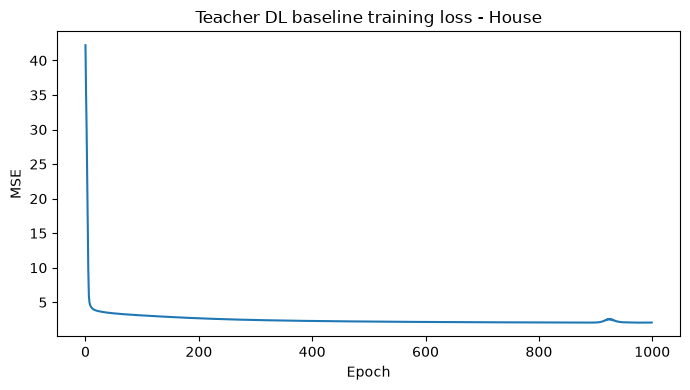

In [16]:
X_train_h_dense = to_dense_array(X_train_h_ready)
X_test_h_dense = to_dense_array(X_test_h_ready)
y_train_h_np = y_train_h.to_numpy().astype(float)
y_test_h_np = y_test_h.to_numpy().astype(float)

teacher_house_params, teacher_house_loss = train_teacher_regression_dnn(
    X_train_h_dense,
    y_train_h_np,
    input_dim=X_train_h_dense.shape[1],
    epochs=1000,
    learning_rate=0.01,
    seed=SEED,
)
teacher_house_pred, _ = teacher_forward_regression(X_test_h_dense, teacher_house_params)
teacher_house_pred = np.maximum(teacher_house_pred.ravel(), 0)
teacher_house_metrics = pd.DataFrame(
    [regression_metrics_row("Teacher DL Baseline", y_test_h_np, teacher_house_pred)]
)
display(teacher_house_metrics.round(4))

if HAS_MATPLOTLIB:
    plt.figure(figsize=(7, 4))
    plt.plot(teacher_house_loss)
    plt.title("Teacher DL baseline training loss - House")
    plt.xlabel("Epoch")
    plt.ylabel("MSE")
    plt.tight_layout()
    plt.show()

**Nhận xét.** DL baseline đạt RMSE = 1.457 tỷ VND, gần Random Forest nhưng chưa tốt hơn. Việc chỉ dùng MSE trực tiếp trên target gốc làm baseline nhạy với scale giá.


---

### 18. Improved DNN

Improved DNN train trên standardized log price, dùng validation split, hidden layers lớn hơn, mini-batch, L2 regularization và early stopping.


,Model,MAE,MSE,RMSE,R2,MAPE
0,Improved DNN,1.0648,2.0077,1.4169,0.5799,21.2207


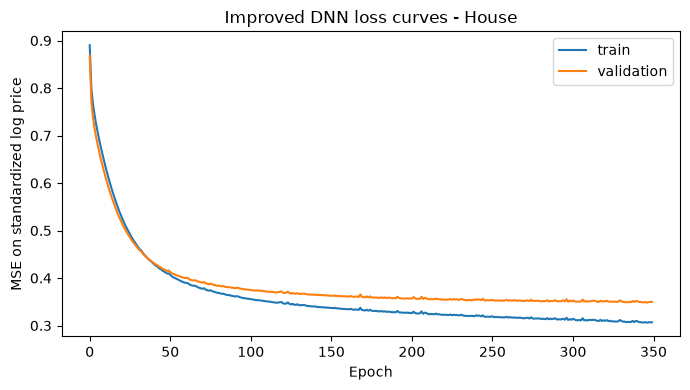

In [17]:
X_h_train_nn, X_h_val_nn, y_h_train_nn, y_h_val_nn = train_test_split(
    X_train_h_dense,
    y_train_h_np,
    test_size=0.20,
    random_state=SEED,
)
y_h_train_log = np.log1p(y_h_train_nn)
y_h_val_log = np.log1p(y_h_val_nn)
y_h_log_mean = y_h_train_log.mean()
y_h_log_std = y_h_train_log.std() + 1e-8
y_h_train_scaled = (y_h_train_log - y_h_log_mean) / y_h_log_std
y_h_val_scaled = (y_h_val_log - y_h_log_mean) / y_h_log_std

improved_house_params, improved_house_history = train_improved_regression_dnn(
    X_h_train_nn,
    y_h_train_scaled,
    X_h_val_nn,
    y_h_val_scaled,
    hidden=(64, 32),
    epochs=350,
    learning_rate=0.01,
    batch_size=512,
    l2=1e-4,
    patience=35,
    seed=SEED,
)

improved_house_pred_scaled, _ = improved_forward_regression(
    X_test_h_dense, improved_house_params
)
improved_house_pred_log = (
    improved_house_pred_scaled.ravel() * y_h_log_std + y_h_log_mean
)
improved_house_pred = np.maximum(np.expm1(improved_house_pred_log), 0)
improved_house_row = regression_metrics_row(
    "Improved DNN", y_test_h_np, improved_house_pred
)
display(pd.DataFrame([improved_house_row]).round(4))

if HAS_MATPLOTLIB:
    plt.figure(figsize=(7, 4))
    plt.plot(improved_house_history["train_loss"], label="train")
    plt.plot(improved_house_history["val_loss"], label="validation")
    plt.title("Improved DNN loss curves - House")
    plt.xlabel("Epoch")
    plt.ylabel("MSE on standardized log price")
    plt.legend()
    plt.tight_layout()
    plt.show()

**Nhận xét.** Improved DNN giảm RMSE từ 1.457 xuống 1.417 tỷ VND và tăng R2 từ 0.556 lên 0.580. Standardized log target giúp training ổn định hơn baseline.


---

### 19. So sánh DL

So sánh DL baseline với Improved DNN.


In [18]:
house_dl_comparison = pd.concat(
    [teacher_house_metrics, pd.DataFrame([improved_house_row])],
    ignore_index=True,
)
display(house_dl_comparison.round(4))

,Model,MAE,MSE,RMSE,R2,MAPE
0,Teacher DL Baseline,1.1147,2.1223,1.4568,0.5559,22.8246
1,Improved DNN,1.0648,2.0077,1.4169,0.5799,21.2207


---

### 20. So sánh 6 mô hình cuối

Bảng cuối gồm 5 regression models và Improved DNN.


,Model,MAE,MSE,RMSE,R2,MAPE
5,Improved DNN,1.0648,2.0077,1.4169,0.5799,21.2207
0,Random Forest Regressor,1.0801,2.0733,1.4399,0.5662,22.3059
1,KNN Regressor,1.1913,2.4745,1.5731,0.4822,25.0126
2,Gradient Boosting Regressor,1.2375,2.4998,1.5811,0.4769,25.8718
3,Decision Tree Regressor,1.2617,2.7049,1.6446,0.4340,26.4670
4,Linear Regression,8.2353,54357.5557,233.1471,-11373.5483,222.6192


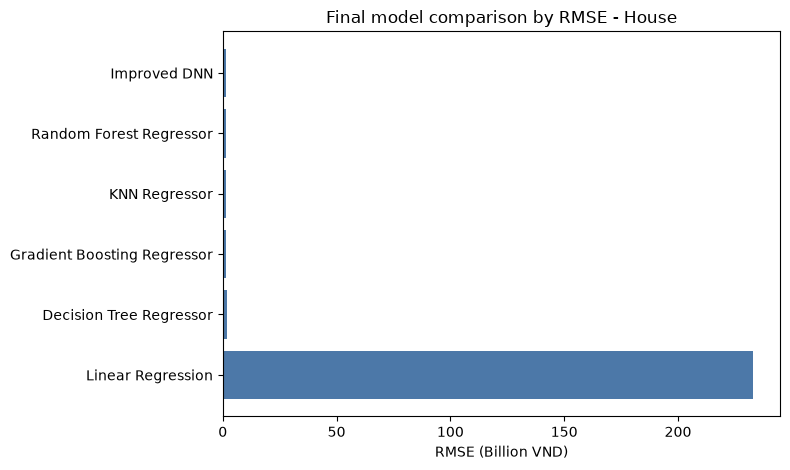

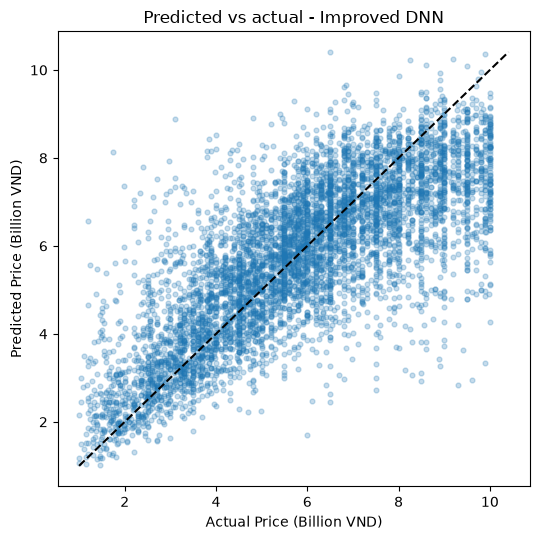

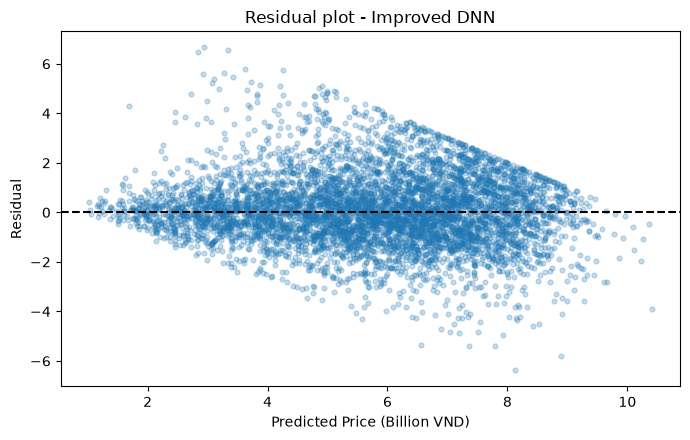

In [19]:
final_house_comparison = pd.concat(
    [house_ml_results, pd.DataFrame([improved_house_row])],
    ignore_index=True,
)
final_house_comparison = final_house_comparison[
    ["Model", "MAE", "MSE", "RMSE", "R2", "MAPE"]
]
assert len(final_house_comparison) == 6
assert "Teacher DL Baseline" not in final_house_comparison["Model"].tolist()
display(final_house_comparison.sort_values("RMSE").round(4))

best_house_model_name = final_house_comparison.sort_values("RMSE").iloc[0]["Model"]
if best_house_model_name == "Improved DNN":
    best_house_pred = improved_house_pred
else:
    best_house_pred = np.maximum(
        fitted_house_ml_models[best_house_model_name].predict(X_test_h), 0
    )

if HAS_MATPLOTLIB:
    chart_df = final_house_comparison.sort_values("RMSE", ascending=False)
    plt.figure(figsize=(8, 4.8))
    plt.barh(chart_df["Model"], chart_df["RMSE"], color="#4C78A8")
    plt.xlabel("RMSE (Billion VND)")
    plt.title("Final model comparison by RMSE - House")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(5.5, 5.5))
    plt.scatter(y_test_h_np, best_house_pred, alpha=0.25, s=12)
    lo = min(y_test_h_np.min(), best_house_pred.min())
    hi = max(y_test_h_np.max(), best_house_pred.max())
    plt.plot([lo, hi], [lo, hi], color="black", linestyle="--")
    plt.xlabel("Actual Price (Billion VND)")
    plt.ylabel("Predicted Price (Billion VND)")
    plt.title(f"Predicted vs actual - {best_house_model_name}")
    plt.tight_layout()
    plt.show()

    residuals = y_test_h_np - best_house_pred
    plt.figure(figsize=(7, 4.5))
    plt.scatter(best_house_pred, residuals, alpha=0.25, s=12)
    plt.axhline(0, color="black", linestyle="--")
    plt.xlabel("Predicted Price (Billion VND)")
    plt.ylabel("Residual")
    plt.title(f"Residual plot - {best_house_model_name}")
    plt.tight_layout()
    plt.show()

**Nhận xét.** Improved DNN là model tốt nhất theo RMSE (1.417), nhỉnh hơn Random Forest (1.440). Khoảng cách nhỏ, nên kết luận hợp lý là DL cải thiện nhẹ chứ không vượt trội tuyệt đối.


In [20]:
best_house_row = final_house_comparison.sort_values("RMSE").iloc[0]
print("Best final house model:", best_house_row["Model"])
print("Primary metric RMSE:", round(float(best_house_row["RMSE"]), 4), "billion VND")
print(
    "Did Improved DNN beat all classical ML by RMSE?:",
    bool(best_house_row["Model"] == "Improved DNN"),
)

Best final house model: Improved DNN
Primary metric RMSE: 1.4169 billion VND
Did Improved DNN beat all classical ML by RMSE?: True


---

### 21. Đóng gói pipeline

Lưu model tốt nhất, preprocessor, metadata, feature schema, demo input và demo prediction. Artifact được load lại để kiểm tra inference.


In [21]:
PIPELINE_ARTIFACT_DIR = ROOT / "pipeline" / "house_price"
PIPELINE_ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)


def json_safe(value):
    if isinstance(value, dict):
        return {str(k): json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_safe(v) for v in value]
    if isinstance(value, np.ndarray):
        return value.tolist()
    if isinstance(value, (np.integer,)):
        return int(value)
    if isinstance(value, (np.floating,)):
        return float(value)
    if isinstance(value, (np.bool_,)):
        return bool(value)
    try:
        if pd.isna(value):
            return None
    except (TypeError, ValueError):
        pass
    return value


def write_json(path, payload):
    path.write_text(
        json.dumps(json_safe(payload), indent=2, ensure_ascii=False), encoding="utf-8"
    )


def relative_path(path):
    return str(Path(path).relative_to(ROOT)).replace("\\", "/")


def metrics_from_row(row, columns):
    return {col: json_safe(row[col]) for col in columns}


HOUSE_METRIC_COLUMNS = ["MAE", "MSE", "RMSE", "R2", "MAPE"]
assert len(final_house_comparison) == 6
assert "Teacher DL Baseline" not in final_house_comparison["Model"].tolist()

best_house_row = final_house_comparison.sort_values("RMSE").iloc[0]
selected_house_model = str(best_house_row["Model"])

model_path = PIPELINE_ARTIFACT_DIR / (
    "model.npz" if selected_house_model == "Improved DNN" else "model.joblib"
)
preprocessor_path = PIPELINE_ARTIFACT_DIR / "preprocessor.joblib"
metadata_path = PIPELINE_ARTIFACT_DIR / "metadata.json"
schema_path = PIPELINE_ARTIFACT_DIR / "feature_schema.json"
demo_input_path = PIPELINE_ARTIFACT_DIR / "demo_input.json"
demo_prediction_path = PIPELINE_ARTIFACT_DIR / "demo_prediction.json"
final_table_path = PIPELINE_ARTIFACT_DIR / "final_comparison.csv"
dl_table_path = PIPELINE_ARTIFACT_DIR / "dl_comparison.csv"

if selected_house_model == "Improved DNN":
    np.savez(model_path, **improved_house_params)
    joblib.dump(house_preprocessor, preprocessor_path)
    model_format = "NumPy DNN weights (.npz) + joblib ColumnTransformer"
else:
    selected_pipeline = fitted_house_ml_models[selected_house_model]
    joblib.dump(selected_pipeline, model_path)
    preprocessor_obj = selected_pipeline.regressor_.named_steps.get(
        "preprocessor", house_preprocessor
    )
    joblib.dump(preprocessor_obj, preprocessor_path)
    model_format = "joblib sklearn TransformedTargetRegressor"

final_house_comparison.to_csv(final_table_path, index=False)
house_dl_comparison.to_csv(dl_table_path, index=False)

house_feature_details = {
    "Area_m2": (
        "number",
        "Positive property area after unit normalization.",
        "m2",
        "Property area.",
    ),
    "Frontage_m": (
        "number",
        "Positive frontage width or missing.",
        "m",
        "Street frontage width.",
    ),
    "Access_Road_m": (
        "number",
        "Positive access-road width or missing.",
        "m",
        "Road/access width.",
    ),
    "Floors": (
        "number",
        "Positive floor count or missing.",
        "floors",
        "Number of floors.",
    ),
    "Bedrooms": (
        "number",
        "Non-negative bedroom count or missing.",
        "rooms",
        "Number of bedrooms.",
    ),
    "Bathrooms": (
        "number",
        "Non-negative bathroom count or missing.",
        "rooms",
        "Number of bathrooms.",
    ),
    "city": (
        "string",
        "Seen city values; unseen values handled by encoder.",
        None,
        "City/province parsed from address.",
    ),
    "district": (
        "string",
        "Seen district values; unseen values handled by encoder.",
        None,
        "District parsed from address.",
    ),
    "Legal status": (
        "string",
        "Seen legal-status values; Unknown allowed for missing.",
        None,
        "Legal status from source listing.",
    ),
    "Furniture state": (
        "string",
        "Seen furniture-state values; Unknown allowed for missing.",
        None,
        "Furniture condition from source listing.",
    ),
    "House direction": (
        "string",
        "Seen direction values; Unknown allowed for missing.",
        None,
        "House direction from source listing.",
    ),
    "Balcony direction": (
        "string",
        "Seen direction values; Unknown allowed for missing.",
        None,
        "Balcony direction from source listing.",
    ),
}
house_feature_schema = {
    "task_name": "Vietnam House Price Regression",
    "target": HOUSE_TARGET,
    "target_unit": "billion VND",
    "prediction_time_input": "One listing row with normalized numeric fields and parsed location/categorical fields.",
    "feature_order": HOUSE_FEATURES,
    "features": [
        {
            "name": name,
            "type": house_feature_details[name][0],
            "required": True,
            "allowed_or_category_notes": house_feature_details[name][1],
            "unit": house_feature_details[name][2],
            "description": house_feature_details[name][3],
        }
        for name in HOUSE_FEATURES
    ],
}

house_metadata = {
    "task_name": "Vietnam House Price Regression",
    "task_type": "regression",
    "dataset_name": "House Price Prediction Dataset Vietnam 2024",
    "dataset_path": relative_path(HOUSE_PATH),
    "target": HOUSE_TARGET,
    "target_unit": "billion VND",
    "selected_model": selected_house_model,
    "selection_metric": "RMSE",
    "metrics": metrics_from_row(best_house_row, HOUSE_METRIC_COLUMNS),
    "feature_count": int(len(HOUSE_FEATURES)),
    "transformed_feature_count": int(X_train_h_ready.shape[1]),
    "training_date": datetime.now(timezone.utc).replace(microsecond=0).isoformat(),
    "preprocessing_summary": "Numeric median imputation + scaling; categorical Unknown imputation + one-hot encoding, all fitted on training split only.",
    "target_transformation": "Improved DNN trains on standardized log1p target and inverse-transforms predictions with expm1 for final metrics.",
    "target_log_mean": float(y_h_log_mean),
    "target_log_std": float(y_h_log_std),
    "model_format": model_format,
    "model_file": relative_path(model_path),
    "preprocessor_file": relative_path(preprocessor_path),
    "notes": [
        "Price-derived price_per_m2_million is used only for EDA and excluded from X.",
        "Final metrics are reported in original billion-VND units.",
    ],
}

demo_input = {col: json_safe(X_house.iloc[0][col]) for col in HOUSE_FEATURES}
assert HOUSE_TARGET not in demo_input
assert "price_per_m2_million" not in demo_input

write_json(metadata_path, house_metadata)
write_json(schema_path, house_feature_schema)
write_json(demo_input_path, demo_input)

demo_df = pd.DataFrame([demo_input], columns=HOUSE_FEATURES)
if selected_house_model == "Improved DNN":
    loaded_preprocessor = joblib.load(preprocessor_path)
    demo_ready = to_dense_array(loaded_preprocessor.transform(demo_df))
    with np.load(model_path) as loaded:
        loaded_params = {key: loaded[key] for key in loaded.files}
    demo_pred_scaled, _ = improved_forward_regression(demo_ready, loaded_params)
    demo_pred_log = float(demo_pred_scaled.ravel()[0]) * float(y_h_log_std) + float(
        y_h_log_mean
    )
    predicted_price = max(float(np.expm1(demo_pred_log)), 0.0)
else:
    loaded_model = joblib.load(model_path)
    predicted_price = max(float(loaded_model.predict(demo_df)[0]), 0.0)

demo_prediction = {
    "model": selected_house_model,
    "predicted_price_billion_vnd": predicted_price,
}
write_json(demo_prediction_path, demo_prediction)

for json_path in [metadata_path, schema_path, demo_input_path, demo_prediction_path]:
    json.loads(json_path.read_text(encoding="utf-8"))
for path in [
    model_path,
    preprocessor_path,
    metadata_path,
    schema_path,
    demo_input_path,
    demo_prediction_path,
    final_table_path,
    dl_table_path,
]:
    assert path.exists(), f"Missing artifact: {path}"

display(pd.DataFrame([demo_prediction]))
print("Saved house-price artifacts:")
for path in sorted(PIPELINE_ARTIFACT_DIR.iterdir()):
    print("-", relative_path(path))

,model,predicted_price_billion_vnd
0,Improved DNN,8.961255


Saved house-price artifacts:
- pipeline/house_price/demo_input.json
- pipeline/house_price/demo_prediction.json
- pipeline/house_price/dl_comparison.csv
- pipeline/house_price/feature_schema.json
- pipeline/house_price/final_comparison.csv
- pipeline/house_price/metadata.json
- pipeline/house_price/model.npz
- pipeline/house_price/preprocessor.joblib
